# KNN — Classification & Regression

---

## 1. Problem Setup

Assume we have a dataset

$$
\{(x_i, y_i)\}_{i=1}^{N}
$$

where

$$
x_i \in \mathbb{R}^D
$$

is the feature vector and

$$
y_i \in \mathbb{R} \quad \text{(for regression) or} \quad y_i \in \{1,2,\dots,K\} \quad \text{(for classification)}
$$

is the target value or class label.

The goal is to predict the output for new inputs based on similarity to the training data.

---

## 2. Distance-Based Model

The K-Nearest Neighbors approach predicts based on the **closest points in feature space**.

The squared Euclidean distance between a test point $x_{\text{test},i}$ and a training point $x_{\text{train},j}$ is:

$$
d_{ij} = \| x_{\text{test},i} - x_{\text{train},j} \|_2^2
= \sum_{k=1}^D \left( x_{\text{test},i}^{(k)} - x_{\text{train},j}^{(k)} \right)^2
$$


---

## 3. Selecting Neighbors

For each test point, select the indices of the **top \(k\) smallest distances**:

$$
\mathcal{N}_i = \text{indices of the k nearest neighbors of } x_{\text{test},i}
$$

---

## 4. Prediction Rule — Classification

For **classification**, predict the most common class among neighbors:

$$
\hat{y}_i = \text{mode}\{ y_j : j \in \mathcal{N}_i \}
$$

---

## 5. Prediction Rule — Regression

For **regression**, predict the mean of neighbor values:

$$
\hat{y}_i = \frac{1}{k} \sum_{j \in \mathcal{N}_i} y_j
$$

---

## 6. Algorithm Steps

1. Compute distance matrix between test points and training points:

$$
D_{ij} = \| x_{\text{test},i} - x_{\text{train},j} \|_2^2
$$

2. Select the indices of the \(k\) nearest neighbors for each test point:

$$
\mathcal{N}_i = \text{argsort}(D_{i,:})[:k]
$$

3. Gather neighbor outputs:

$$
y_{\mathcal{N}_i} = \{ y_j : j \in \mathcal{N}_i \}
$$

4. Predict based on task:

$$
\hat{y}_i =
\begin{cases}
\text{mode}(y_{\mathcal{N}_i}), & \text{classification} \\
\text{mean}(y_{\mathcal{N}_i}), & \text{regression}
\end{cases}
$$

---

## 7. Initialization

- Number of neighbors: $k = \text{n\_neighbours}$ 
- Task type: classification or regression  
- Inputs: training features $X_{\text{train}}$ and labels $y_{\text{train}}$

---

## 8. Computational Notes

- Distance computation is **vectorized** for efficiency.  
- For **classification**, `mode` selects the majority class.  
- For **regression**, the `mean` of neighbors provides a smooth estimate.  

---

## 9. Prediction Summary

After storing the training data, predictions for new inputs $X_{\text{test}}$ are:

$$
\hat{y}_{\text{test}} = \text{KNN\_Classifier\_Regressor.predict}(X_{\text{train}}, X_{\text{test}}, y_{\text{train}})
$$

Returns predicted class (classification) or value (regression) for each test point.

---

## 10. Geometric Interpretation

- KNN learns a **local decision surface**.  
- **Classification:** space divided into regions where each region predicts the majority class of neighbors.  
- **Regression:** surface is smoothed by averaging nearby values.  

In [1]:
class KNN_Classifier_Regressor:
    """
    K-Nearest Neighbors (KNN) classifier and regressor.

    This class implements a simple KNN algorithm that can be used for both 
    classification and regression tasks. Predictions are made based on the 
    majority vote (classification) or mean value (regression) of the k nearest neighbors.

    Parameters
    ----------
    n_neighbours : int, default=3
        Number of neighbors (k) to use for predictions.
    task_classify : bool, default=True
        If True, performs classification; if False, performs regression.
    """
    

    def __init__(self,n_neighbours=3, task_classify=True):
        self.n_neighbours = n_neighbours
        self.task_classify = task_classify
        

    def _dmatrix(self, X_test , X_train):
        """
        Compute the squared Euclidean distance matrix between test points and training points.

        Parameters
        ----------
        X_test : ndarray of shape (N_test, D)
            Test data features.
        X_train : ndarray of shape (N_train, D)
            Training data features.

        Returns
        -------
        dij : ndarray of shape (N_test, N_train)
            Squared Euclidean distances between each test point and each training point.
        """
        
        # Compute pairwise squared distances using the expansion: ||a-b||^2 = ||a||^2 + ||b||^2 - 2*a.b
        dij =  np.sum(X_test*X_test,axis=1,keepdims=True) + np.sum(X_train*X_train,axis=1) - 2 * X_test @ X_train.T
        
        # Ensure no negative distances due to numerical errors
        dij = np.maximum(dij,0)

        return dij


    def predict(self,X_train , X_test , y_train):
        """
        Predict outputs for test data using KNN.

        Parameters
        ----------
        X_train : ndarray of shape (N_train, D)
            Training data features.
        X_test : ndarray of shape (N_test, D)
            Test data features.
        y_train : ndarray of shape (N_train,)
            Training data labels or target values.

        Returns
        -------
        predictions : ndarray of shape (N_test,)
            Predicted class labels (classification) or values (regression) for each test sample.
        """
        
        from scipy.stats import mode 
        

        # Ensure inputs are numpy arrays
        X_train = np.asarray(X_train)
        X_test = np.asarray(X_test)

        y_train = np.asarray(y_train)
        y_train = y_train.reshape(-1)
        
        # Reshape 1D arrays to 2D (single feature)
        if X_train.ndim == 1:
            X_train = X_train.reshape(-1,1)

        if X_test.ndim == 1:
            X_test = X_test.reshape(-1,1)
            
         
        N = len(X_train)

        
        # Ensure number of neighbors is at least 1 and at most N-1        
        top_k = max(min(self.n_neighbours,N-1),1)
        
        # Compute distance matrix between test points and training points
        d_matrix = self._dmatrix(X_test,X_train)

        # Find the indices of the top_k nearest neighbors for each test point
        top_k_indexes = np.argpartition(d_matrix,top_k,axis=1)[:,:top_k]

        # Gather neighbor labels or values
        neighbour_classes = y_train[top_k_indexes]

        if self.task_classify:
            # Classification: take the mode (majority vote) along neighbors
            predictions = mode(neighbour_classes,axis=1)[0]

        else :
            # Regression: take the mean of neighbors
            predictions = np.mean(neighbour_classes,axis=1)
            
        return predictions
     



## 1. Objective

The objective is to study how the **number of neighbors k** in the K-Nearest Neighbors (KNN) algorithm affects the **misclassification error** on a test dataset. 

---


## 2. Dataset Generation

We generate a **2-dimensional synthetic dataset** with two classes:

- Class \(+1\): centered at \((2,2)\)  
- Class \(-1\): centered at \((-2,-2)\)  


The dataset is split into **training** and **testing** sets for evaluation.

---



## 4. Misclassification Error

For each $k = 1, 2, \dots, N-1$, the misclassification error on test data is computed as:

$$
\text{Error}_k = \frac{1}{N_\text{test}} \sum_{i=1}^{N_\text{test}} \mathbf{1}(\hat{y}_i \neq y_i)
$$

where $\mathbf{1}(\cdot)$ is the indicator function.

---










In [2]:
import numpy as np
import matplotlib.pyplot as plt


# 1. Generate Dataset
np.random.seed(42)
N = 51  # points per class
D = 2   # features

# Class +1: centered at (2,2)
X_pos = np.random.randn(N, D) + 2
y_pos = np.ones(N)

# Class -1: centered at (-2,-2)
X_neg = np.random.randn(N, D) - 2
y_neg = -np.ones(N)

# Combine to form training set
X_train = np.vstack([X_pos, X_neg])
y_train = np.hstack([y_pos, y_neg])

# Test set
X_test = np.random.randn(2*N, D)
y_test = np.where(np.sum(X_test, axis=1) > 0, 1, -1)

In [3]:
# 2. All models 
max_k = N-1 # Max neighbors 
errors = []

for k in range(1, max_k + 1):
    
    model = KNN_Classifier_Regressor(n_neighbours=k , task_classify=True)
    y_pred = model.predict(X_train, X_test, y_train)
    error = np.mean(y_pred != y_test)
    errors.append(error)



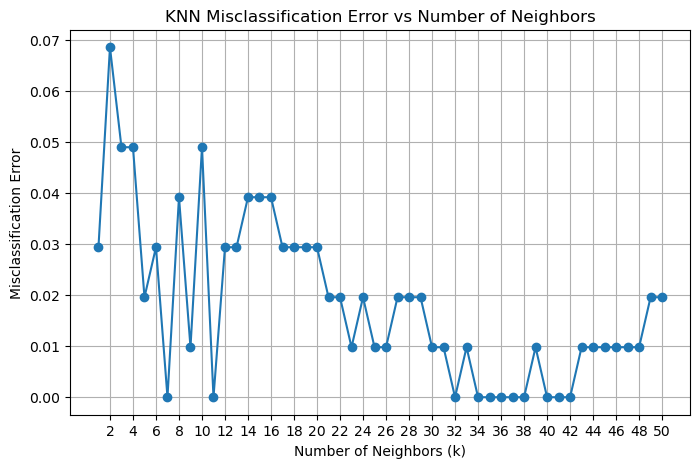

In [4]:
# 3. Plot Misclassification
plt.figure(figsize=(8,5))
plt.plot(range(1, max_k + 1), errors, marker='o')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Misclassification Error")
plt.title("KNN Misclassification Error vs Number of Neighbors")
plt.grid(True)

plt.xticks(ticks=[k for k in range(1, max_k + 1) if k % 2 == 0])

plt.show()

---

## 5. Conclusion
**Observation:** Even values of \(k\) can lead to **higher misclassification** due to ties in majority voting.


1. Small $k$ → model fits closely, more sensitive to noise (high variance).  
2. Large $k$ → model is smoother, may underfit (high bias).  
3. Odd $k$ is preferred in classification to avoid ties.  
4. Optimal $k$ balances bias and variance — can be determined using cross-validation.  

---
